In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [22]:
# load in Breast Cancer Wisconsin (Diagnostic) Data Set
data_path = 'data.csv'
df = pd.read_csv(data_path)

# EXPLORATORY DATA ANALYSIS

In [14]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


The dataset consists of 569 samples, with each sample having 30 quantitative variables associated with it. Each sample also has the target variable of the diagnosis for the patient associated with it.

In [16]:
df['diagnosis'].value_counts() # The dataset contains significantly more benign diagnoses than malignant diagnoses

diagnosis
B    357
M    212
Name: count, dtype: int64

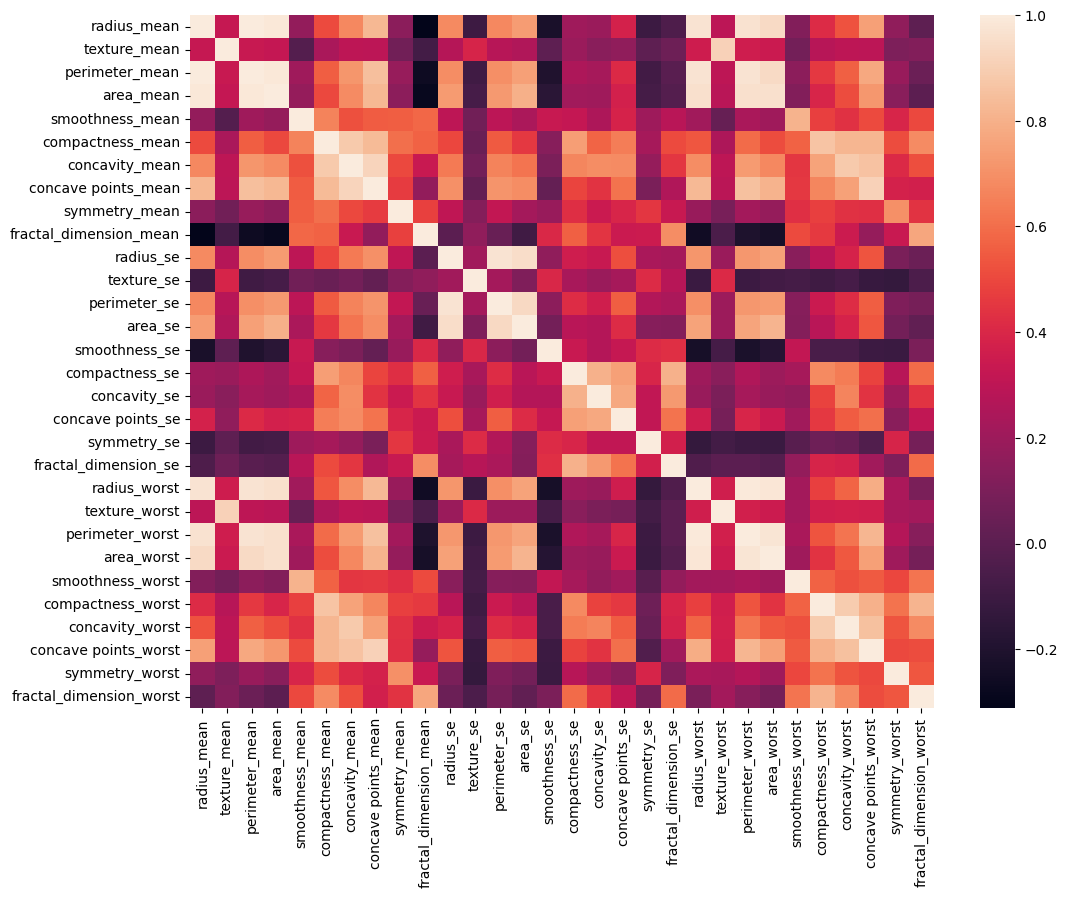

In [54]:
# Create a heatmap of features correlations to each other to find underlying patterns
df_features = df.drop(columns=['diagnosis', 'id', 'Unnamed: 32'], axis=1)

corr_matrix = df_features.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix)
plt.show()

## Findings from Heatmap
A lot of the variables are not significantly correlated or correlated at all to each other. However, there are some variables such as features having to do with area, perimeter, and radius that are correlated to each other. This makes sense because you would intuitively think that a tumor with a relatively large radius will also have a relatively large area and perimeter (and vice versa).

# DATA PREPROCESSING AND FEATURE ENGINEERING

In [55]:
# Create different objects for the features and the target variable
X = df_features
y = df['diagnosis']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  

In [56]:
# Need to convert M (Malignant) to 1 and B (Benign) to 0
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


print("\nEncoded Target (y_encoded):")
print(y_encoded[:5]) # Shows the first 5 entries
print("\nClass Mapping:")
print(f"0: {label_encoder.classes_[0]}, 1: {label_encoder.classes_[1]}")


Encoded Target (y_encoded):
[1 1 1 1 1]

Class Mapping:
0: B, 1: M


In [57]:
# split data into training and testing data properly
from sklearn.model_selection import train_test_split

# Perform the split using our encoded target variable
# random_state = 42 ensures results are reproducible
# stratify = y_encoded ensures ratio of malignant to benign samples in training and testing data is equivalent
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [58]:
# scale data to make training quicker and make post analysis of weights better
from sklearn.preprocessing import StandardScaler

# Create an instance of the scaler
scaler = StandardScaler()

# Fit the scaler on the training data to learn its statistical properties
scaler.fit(X_train)

# Transform both the training and testing data using the fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFirst row of scaled training data:")
print(X_train_scaled[0])
X.head()


First row of scaled training data:
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371 -0.6897715
 -0.68858645 -0.39817525 -1.0391547  -0.82505632 -0.10931776 -0.05597554
 -0.21009621 -0.01591326 -1.00518399 -0.91194199 -0.66281588 -0.65256108
 -0.70188911 -0.27539357  0.5797977   1.31324246  0.46690813  0.44598271
 -0.59615478 -0.63472223 -0.6102273  -0.23574392  0.05456632  0.02183673]


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Model Building

In [59]:
# Get the number of input features from our training data
input_features = X_train_scaled.shape[1]

# Define the model architecture
keras_model = tf.keras.models.Sequential([
    # Input layer and first hidden layer
    tf.keras.layers.Dense(16, activation='relu', input_shape=(input_features,)),
    # Second hidden layer
    tf.keras.layers.Dense(8, activation='relu'),
    # Output layer
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Print model summary
print("TensorFlow/Keras Model Architecture:")
keras_model.summary()

TensorFlow/Keras Model Architecture:


/Users/vinayreddyratnam/ENTER/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training and Evaluation

In [60]:
keras_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [61]:
# Train the model
history = keras_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1 # Use verbose=0 to hide the output for each epoch
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6308 - loss: 0.7009 - val_accuracy: 0.7391 - val_loss: 0.5116
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7702 - loss: 0.5225 - val_accuracy: 0.8478 - val_loss: 0.4082
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8875 - loss: 0.4069 - val_accuracy: 0.9130 - val_loss: 0.3380
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9169 - loss: 0.3310 - val_accuracy: 0.9130 - val_loss: 0.2853
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9413 - loss: 0.2766 - val_accuracy: 0.9565 - val_loss: 0.2436
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9462 - loss: 0.2363 - val_accuracy: 0.9565 - val_loss: 0.2135
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9511 - loss: 0.2054 - val_accuracy: 0.9565 - val_loss: 0.1911
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9633 - loss: 0.1804 - val_accuracy: 0.9565 - v

In [62]:
# Get predicted probabilities
y_pred_proba = keras_model.predict(X_test_scaled)

# Convert probabilities to binary class labels (0 or 1)
y_pred_class = (y_pred_proba > 0.5).astype("int32")

# The Keras output needs to be flattened to a 1D array for scikit-learn
y_pred_numpy = y_pred_class.flatten()
y_test_numpy = y_test

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 



Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.97      1.00      0.99        72
Malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



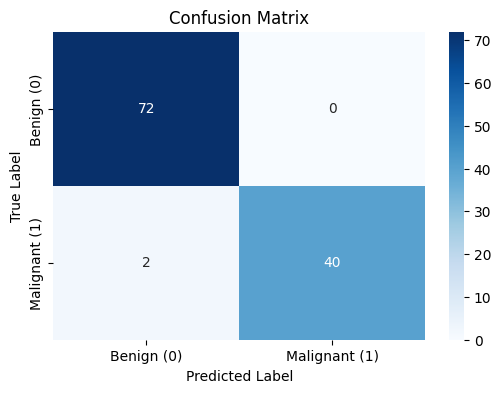

In [63]:
# Final evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Print the classification report
# Recall is key here: What percentage of actual positives did we correctly identify?
print("\nClassification Report:")
print(classification_report(y_test_numpy, y_pred_numpy, target_names=['Benign (0)', 'Malignant (1)']))

# Generate the confusion matrix
cm = confusion_matrix(y_test_numpy, y_pred_numpy)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [66]:
precision = 1.00
recall = 0.95
f1_score = 2 * (precision*recall) / (precision + recall)
print(f"f1 score of model is: {f1_score}")

f1 score of model is: 0.9743589743589743
